## Домашнее задание Кластеризация сигналов сцинтилляционного детектора
ФИО: Рассохин Владислав Романович

#####  Цель:
Целью данной работы является автоматическая кластеризация сигналов, полученных со сцинтилляционного детектора, на основе их параметров. Необходимо разделить 23 479 сигналов на три кластера: два из них соответствуют различным типам частиц (гамма-кванты и нейтроны), а третий - группе аномальных или неидентифицируемых сигналов. Задача решается методами машинного обучения без учителя с последующей интерпретацией результатов кластеризации.

##### Исходные данные:
Был получен текстовый файл, внутри которого находятся табличные  данные формата 23479 x 504. В каждой из 23479 строк содержится 504  значения, первые 4 из которых являются метаданными, описывающими  состояние ФЭУ в момент получения сигнала. Затем идёт 500 значений,  описывающих показания детектора.
(504 = Nan - удален)

##### Задача:
Кластеризовать сигналы на три кластера:

Кластер 0 - сигналы, соответствующие первому типу частиц (гамма-кванты или нейтроны),

Кластер 1 - сигналы, соответствующие второму типу частиц,

Кластер 2 - сигналы, не поддающиеся однозначной классификации (аномальные, смешанные или выбросы).

    Необхоидмо выполнить: 
    - Исследование и анализ датасета;
    - Предобработка данных;
    - Feature Engineering;
    - Подбор признаков, их анализ и оценка важности;
    - Обучение нескольких моделей, их сравнение, подбор гиперпараметров;
    - Выбор лучшей модели и объяснение выбора;    



### Исследование и анализ датасета

Иморт библиотек

In [4]:
import os
import re
import glob
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN, Birch, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from IPython.display import display, Markdown
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from sklearn.ensemble import RandomForestClassifier
import itertools
from sklearn.feature_selection import f_classif
from datetime import datetime, timedelta
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from IPython.display import display, clear_output


warnings.filterwarnings("ignore")

Указание констант

In [5]:
RANDOM_STATE = 42
SILHOUETTE_SAMPLE_SIZE = 23479
N_CLUSTERS = 3

Загрузка данных

In [6]:
df = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)

df_meta = df.iloc[:, :4].copy()

df = df.drop([0, 1, 2, 3, 504], axis=1)
df.columns = list(range(500))
df.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


Информация о датасете

In [7]:
print("Размерность датасета:", df.shape)
print("Количество строк:", df.shape[0])
print("Количество столбцов:", df.shape[1])

Размерность датасета: (23479, 500)
Количество строк: 23479
Количество столбцов: 500


In [8]:
df_meta.columns = ["meta_0", "meta_1", "meta_2", "meta_3"]
df_meta.describe()
print("Метаданные:", df_meta.shape)

Метаданные: (23479, 4)


Просмотр мета данных

In [9]:
display(df_meta.head())


,meta_0,meta_1,meta_2,meta_3
0,2890276,357,113,500
1,4928764,740,359,500
2,9630204,162,499,500
3,15798632,841,123,500
4,20637296,412,348,500


На данном этапе обработка метаданных не требуется



Проверка пропусков

In [10]:
total_missing = df.isna().sum().sum()

print("Общее количество пропусков:", total_missing)

Общее количество пропусков: 0


Типы данных в датасете

In [11]:
dtype_table = (
    df.dtypes
    .astype(str)
    .value_counts()
    .reset_index()
)

dtype_table.columns = ["Тип данных", "Количество столбцов"]

display(dtype_table)

,Тип данных,Количество столбцов
0,int64,500


Количество дубликатов

In [12]:
# Количество полных дубликатов строк в рабочем датасете df
duplicates_count = df.duplicated().sum()

print("Количество полных дубликатов:", duplicates_count)

Количество полных дубликатов: 0


Описательная статистика

In [13]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
count,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,...,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000
mean,14822.972316,14822.958474,14822.970016,14822.989991,14823.003961,14822.978619,14822.968610,14822.954470,14822.963670,14822.968908,...,14822.329017,14822.315686,14822.272073,14822.171728,14822.257123,14822.317092,14822.279399,14822.278163,14822.287789,14822.283743
std,2.805884,2.833516,2.840755,2.852066,2.833412,2.836271,2.831241,2.827526,2.846291,2.814655,...,3.357997,3.373568,3.340707,3.332547,3.290301,3.232245,3.268458,3.251192,3.253340,3.242307
min,14812.000000,14812.000000,14812.000000,14811.000000,14812.000000,14812.000000,14812.000000,14811.000000,14812.000000,14809.000000,...,14800.000000,14798.000000,14802.000000,14796.000000,14802.000000,14801.000000,14798.000000,14804.000000,14800.000000,14802.000000
25%,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,...,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000
50%,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,...,14823.000000,14823.000000,14823.000000,14822.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000
75%,14824.000000,14824.000000,14825.000000,14825.000000,14825.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,...,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000
max,14834.000000,14835.000000,14834.000000,14835.000000,14834.000000,14835.000000,14835.000000,14833.000000,14834.000000,14834.000000,...,14836.000000,14835.000000,14834.000000,14836.000000,14833.000000,14834.000000,14833.000000,14834.000000,14833.000000,14835.000000


Средние арифметические значения варьируют в узком диапазоне от 14 822,95 до 14 823, демонстрируя высокую степень однородности центральных тенденций по всем анализируемым переменным. Стандартное отклонение демонстрирует стабильные значения (σ ≈ 2,80-2,85), что указывает на сопоставимую степень рассеивания данных вокруг среднего по всем столбца.

Близость значений среднего (mean) и медианы (50% percentile) свидетельствует о симметричности распределения данных, приближенного к нормальному распределению.Диапазон значений (min ≈ 14 809-14 812; max ≈ 14 834-14 835) составляет приблизительно 23-26 единиц, что при стандартном отклонении около 2,8 указывает на отсутствие выраженных выбросов в данных.

#### График для первичного EDA формы сигналов

Text(0, 0.5, 'Значение АЦП')

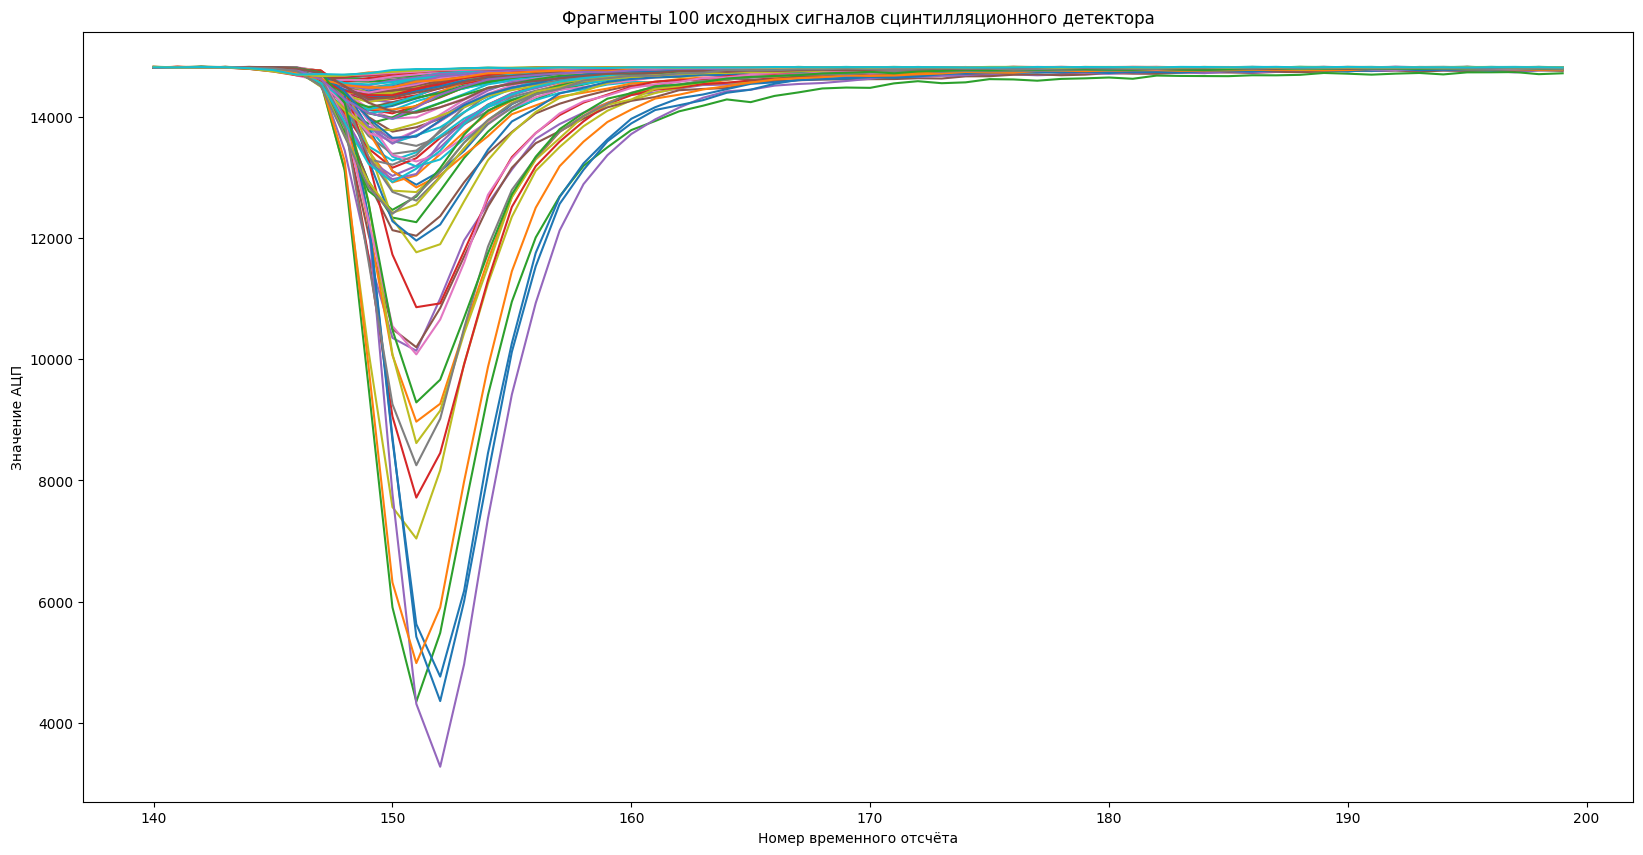

In [14]:
N=range(0,100)
ax = df.T[N][140:200].plot(
    title="Фрагменты 100 исходных сигналов сцинтилляционного детектора",
    legend=None,
    figsize=(20, 10)
)

ax.set_xlabel("Номер временного отсчёта")
ax.set_ylabel("Значение АЦП")

На графике представлены первые 100 сигналов в выбранном временном окне с 140-го по 200-й отсчёт. Видно, что большинство сигналов имеют схожую структуру: до появления импульса значения находятся около стабильного базового уровня, затем наблюдается резкий провал, после которого сигнал постепенно возвращается к исходному уровню.

Минимум сигнала у большинства наблюдений расположен примерно в районе 150–153 отсчёта. Это означает, что импульсы во времени достаточно хорошо выровнены, а выбранное окно корректно захватывает основную информативную часть сигнала.

Также видно, что глубина провала отличается у разных сигналов. Это говорит о различии амплитуд. Кроме того, отличается скорость возвращения к базовой линии: одни сигналы затухают быстрее, другие имеют более длинный хвост. Именно эти различия могут быть полезны для кластеризации, так как они отражают различия формы импульса.

Так как импульс направлен вниз, для дальнейшего анализа удобно выполнить вычитание базовой линии и инвертировать сигнал, чтобы амплитуда стала положительной. После этого можно рассчитывать физически осмысленные признаки: амплитуду, площадь под сигналом, время спада и PSD.

2**14 — это не доказанный факт из описания,
а рабочая гипотеза/приём из исходного кода.

In [15]:
print("Минимум во всём df:", df.min().min())
print("Максимум во всём df:", df.max().max())

print("Минимумы по строкам:")
display(df.min(axis=1).describe())

print("Максимумы по строкам:")
display(df.max(axis=1).describe())

Минимум во всём df: 0
Максимум во всём df: 14838
Минимумы по строкам:


count    23479.000000
mean     12987.861791
std       2389.308983
min          0.000000
25%      12508.000000
50%      14010.000000
75%      14515.000000
max      14719.000000
dtype: float64

Максимумы по строкам:


count    23479.000000
mean     14830.711359
std          1.458499
min      14827.000000
25%      14830.000000
50%      14831.000000
75%      14832.000000
max      14838.000000
dtype: float64

Почти у каждого сигнала верхний уровень около 14830. То есть сигнал в исходном виде сидит на высокой базовой линии, а импульс уходит вниз.

#### График инвертированные сигналы после приведения базовой линии к нулю

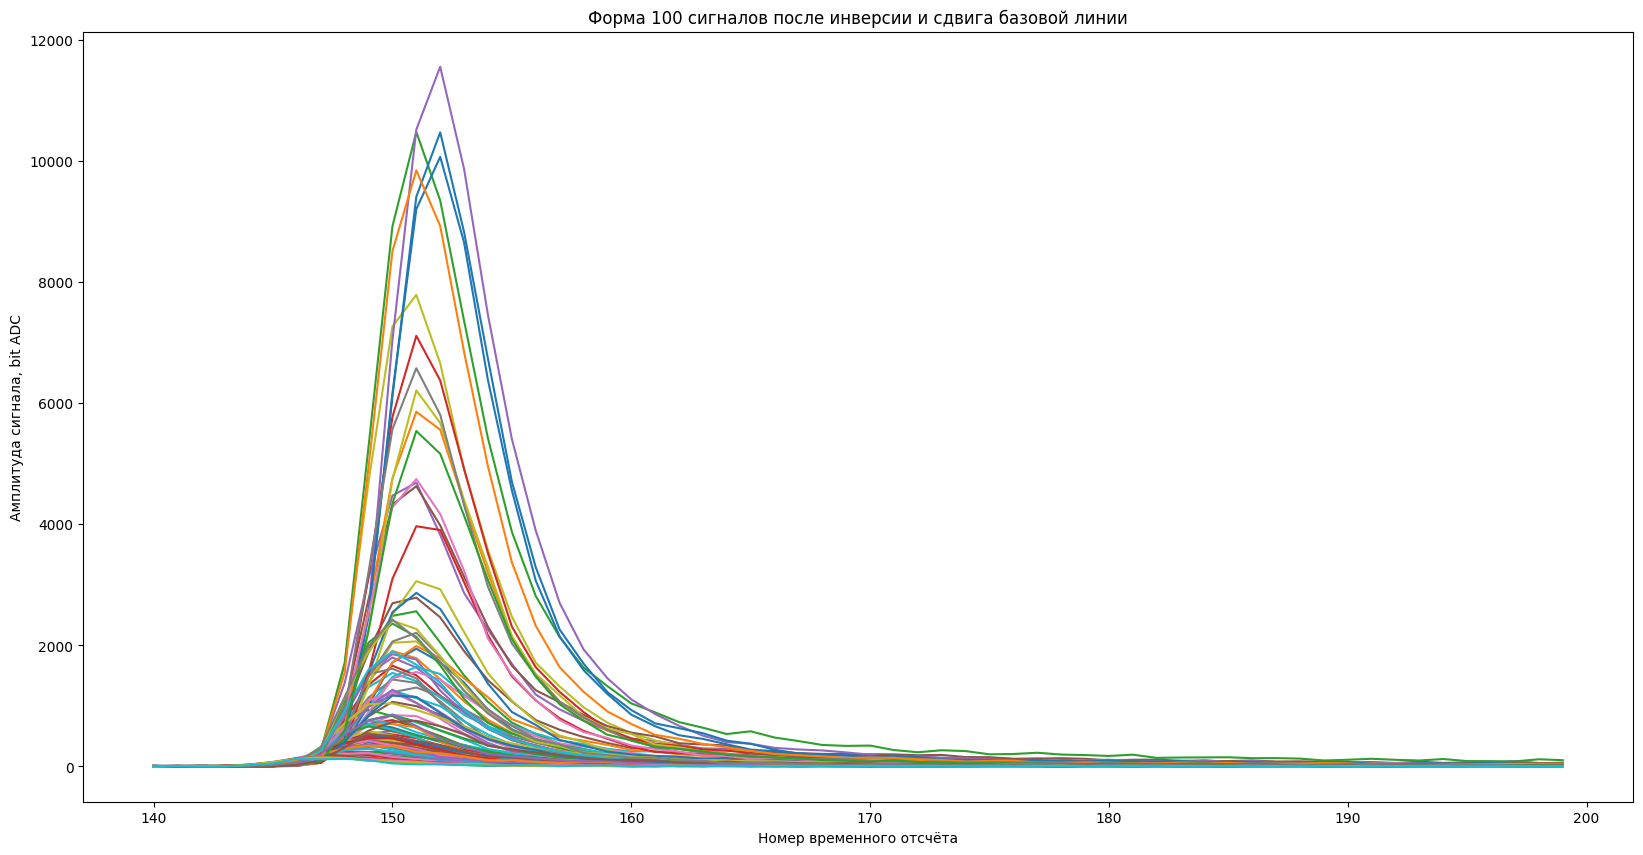

,signal_index,peak_position_full,peak_amplitude_full,peak_position_fragment,peak_amplitude_fragment,area_fragment,mean_fragment,std_fragment,min_fragment
0,0,149,533,149,533,4165,69.416667,119.003104,1
1,1,150,1903,150,1903,11821,197.016667,437.803822,0
2,2,151,2560,151,2560,16428,273.716667,603.475586,-4
3,3,149,566,149,566,4221,70.283333,130.515028,-3
4,4,150,1796,150,1796,11456,190.933333,419.135141,0
...,...,...,...,...,...,...,...,...,...
95,95,151,752,151,752,6288,104.750000,183.737066,-3
96,96,148,135,148,135,1135,18.750000,34.338112,-3
97,97,150,2422,150,2422,15094,251.566667,552.881002,2
98,98,147,148,147,148,986,15.933333,34.492380,-4


Размер таблицы характеристик:
(100, 9)


In [16]:

N = range(0, 100)

# Подготовка сигнала: инверсия и сдвиг базовой линии
prepared_signal = 2**14 - df - 1560

# Фрагмент сигнала, по которому строится график
signal_fragment = prepared_signal.iloc[N, 140:200]

# Строим график
ax = signal_fragment.T.plot(
    title="Форма 100 сигналов после инверсии и сдвига базовой линии",
    legend=None,
    figsize=(20, 10)
)

ax.set_xlabel("Номер временного отсчёта")
ax.set_ylabel("Амплитуда сигнала, bit ADC")

plt.show()


# Таблица характеристик сигналов
peak_table = pd.DataFrame({
    "signal_index": list(N),

    # Положение максимального значения во всём сигнале
    "peak_position_full": prepared_signal.iloc[N].idxmax(axis=1).to_numpy(),

    # Максимальная амплитуда во всём сигнале
    "peak_amplitude_full": prepared_signal.iloc[N].max(axis=1).to_numpy(),

    # Положение максимума только на участке 140:200
    "peak_position_fragment": signal_fragment.idxmax(axis=1).to_numpy(),

    # Максимальная амплитуда только на участке 140:200
    "peak_amplitude_fragment": signal_fragment.max(axis=1).to_numpy(),

    # Площадь положительной части сигнала на участке 140:200
    "area_fragment": np.clip(signal_fragment.to_numpy(), 0, None).sum(axis=1),

    # Среднее значение амплитуды на участке 140:200
    "mean_fragment": signal_fragment.mean(axis=1).to_numpy(),

    # Стандартное отклонение амплитуды на участке 140:200
    "std_fragment": signal_fragment.std(axis=1).to_numpy(),

    # Минимальное значение на участке 140:200
    "min_fragment": signal_fragment.min(axis=1).to_numpy()
})

display(peak_table)

print("Размер таблицы характеристик:")
print(peak_table.shape)

В исходном коде для инверсии сигнала используется значение 2**14 = 16384. Это соответствует предположению о 14-битном диапазоне АЦП. В рамках обработки такая операция переводит отрицательный импульс, представленный как провал, в положительный пик. 

На графике представлены 100 сигналов после инверсии и сдвига базовой линии. В сырых данных импульс был направлен вниз, поэтому была выполнена инверсия значений через выражение 2^14 - signal. После дополнительного сдвига базовая линия оказалась расположена около нуля, что делает форму импульса более удобной для анализа.

В выбранном окне с 140-го по 200-й отсчёт хорошо видна основная информативная часть сигнала. Большинство импульсов достигают максимума примерно в районе 151–153 отсчёта, после чего постепенно затухают и возвращаются к базовой линии.

Сигналы заметно отличаются по амплитуде, площади под кривой и скорости затухания. Эти различия важны для дальнейшей кластеризации, так как разные типы частиц могут формировать импульсы разной формы. Поэтому на следующих этапах целесообразно рассчитывать признаки формы сигнала: амплитуду, площадь, время спада, отношение короткой и длинной площади PSD, а также признаки на основе PCA.

#### Предобработка данных

In [17]:

# Берём таблицу с 500 отсчётами сигнала
signals_raw = df.copy()


signals_raw = signals_raw.astype(float)

# Инвертируем сигнал: в исходных данных импульс был провалом вниз
signals_inverted = 2**14 - signals_raw

# Для каждого сигнала считаем свою базовую линию по первым 50 отсчётам
baseline = signals_inverted.iloc[:, :50].mean(axis=1)

# Вычитаем базовую линию, чтобы фон был около нуля
signals_processed = signals_inverted.sub(baseline, axis=0)

print("Размерность обработанных сигналов:", signals_processed.shape)

display(signals_processed.head())

Размерность обработанных сигналов: (23479, 500)


,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,1.48,-1.52,-2.52,-0.52,3.48,1.48,-2.52,-0.52,1.48,1.48,...,-6.52,-0.52,6.48,6.48,4.48,2.48,1.48,-0.52,1.48,2.48
1,2.48,0.48,2.48,-3.52,-1.52,0.48,2.48,0.48,-0.52,1.48,...,-5.52,5.48,-1.52,0.48,-1.52,3.48,2.48,3.48,0.48,2.48
2,1.90,1.90,-0.10,-3.10,1.90,-2.10,-2.10,2.90,-1.10,-2.10,...,1.90,0.90,1.90,1.90,3.90,0.90,-1.10,1.90,1.90,0.90
3,-5.44,0.56,4.56,-1.44,-1.44,0.56,2.56,0.56,-1.44,2.56,...,-1.44,-3.44,0.56,1.56,2.56,-5.44,2.56,0.56,-0.44,0.56
4,-1.40,6.60,-1.40,0.60,-5.40,1.60,-1.40,-2.40,5.60,0.60,...,1.60,1.60,-1.40,-6.40,-2.40,1.60,-2.40,-2.40,-0.40,-3.40


Выполнена предобработка временных сигналов сцинтилляционного детектора. В результате фон каждого импульса приводится приблизительно к нулевому уровню. Это позволяет сравнивать сигналы между собой независимо от индивидуального смещения базовой линии. Эти обработанные сигналы далее могут использоваться для извлечения физических признаков: амплитуды, площади под импульсом, положения пика, PSD-характеристик и параметров времени спада.

### Feature Engineering

In [18]:
# Матрица обработанных сигналов:
# строки — отдельные сигналы,
# столбцы — временные отсчёты
X_signal = signals_processed.to_numpy()

# n_samples — количество сигналов
# n_points — количество временных отсчётов в каждом сигнале
n_samples, n_points = X_signal.shape


# peak_idx — номер временного отсчёта, в котором сигнал достигает максимума
# amplitude — максимальная амплитуда сигнала
peak_idx = np.argmax(X_signal, axis=1)
amplitude = np.max(X_signal, axis=1)


# positive_signal — сигнал, в котором отрицательные значения заменены на 0
# total_area — полная площадь положительной части сигнала
positive_signal = np.clip(X_signal, 0, None)
total_area = positive_signal.sum(axis=1)


# noise_mean — среднее значение базовой линии на первых 50 отсчётах
# noise_std — стандартное отклонение шума на первых 50 отсчётах
noise_mean = signals_processed.iloc[:, :50].mean(axis=1).to_numpy()
noise_std = signals_processed.iloc[:, :50].std(axis=1).to_numpy()


# short_gate — длина короткого окна после пика
# long_gate — длина длинного окна после пика
short_gate = 12
long_gate = 80


# short_area — площадь сигнала в коротком окне после пика
# long_area — площадь сигнала в длинном окне после пика
short_area = np.zeros(n_samples)
long_area = np.zeros(n_samples)


# decay_50 — время спада сигнала до 50% от максимальной амплитуды
# decay_20 — время спада сигнала до 20% от максимальной амплитуды
# decay_10 — время спада сигнала до 10% от максимальной амплитуды
decay_50 = np.full(n_samples, np.nan)
decay_20 = np.full(n_samples, np.nan)
decay_10 = np.full(n_samples, np.nan)


# tail_area_after_20 — площадь хвостовой части сигнала
# после 20 отсчётов от положения пика
tail_area_after_20 = np.zeros(n_samples)


for i in range(n_samples):
    # p — положение пика текущего сигнала
    # amp — амплитуда текущего сигнала
    p = peak_idx[i]
    amp = amplitude[i]
    
    # Границы длинного и короткого окон после пика
    long_end = min(p + long_gate, n_points)
    short_end = min(p + short_gate, n_points)
    
    # Фрагменты сигнала в длинном и коротком окнах
    long_part = positive_signal[i, p:long_end]
    short_part = positive_signal[i, p:short_end]
    
    # Расчёт площади в длинном и коротком окнах
    long_area[i] = long_part.sum()
    short_area[i] = short_part.sum()
    
    # Участок сигнала после пика
    after_peak = X_signal[i, p:]
    
    # Поиск времени спада до 50%, 20% и 10% от амплитуды
    if amp > 0:
        below_50 = np.where(after_peak <= amp * 0.50)[0]
        below_20 = np.where(after_peak <= amp * 0.20)[0]
        below_10 = np.where(after_peak <= amp * 0.10)[0]
        
        if len(below_50) > 0:
            decay_50[i] = below_50[0]
            
        if len(below_20) > 0:
            decay_20[i] = below_20[0]
            
        if len(below_10) > 0:
            decay_10[i] = below_10[0]
    
    # Расчёт площади хвоста после 20 отсчётов от пика
    tail_start = min(p + 20, n_points)
    tail_area_after_20[i] = positive_signal[i, tail_start:].sum()


# psd — доля медленной компоненты сигнала
# Чем выше psd, тем больше вклад хвоста/медленного затухания
psd = np.where(
    long_area > 0,
    (long_area - short_area) / long_area,
    0
)


# area_to_amplitude — отношение полной площади к амплитуде
# Характеризует условную ширину импульса
area_to_amplitude = np.where(
    amplitude > 0,
    total_area / amplitude,
    0
)


# tail_ratio — доля хвостовой части в общей площади сигнала
# Чем выше tail_ratio, тем более выражен длинный хвост импульса
tail_ratio = np.where(
    total_area > 0,
    tail_area_after_20 / total_area,
    0
)

Для каждого сигнала были определены основные амплитудные параметры, включая максимальную амплитуду импульса и положение его пика во времени. Данные характеристики позволяют оценить интенсивность зарегистрированного события и момент достижения максимального отклика детектора.

Дополнительно была рассчитана полная площадь импульса, отражающая суммарную энергию сигнала. При вычислении площади учитывались только положительные значения после коррекции базовой линии, что позволило исключить влияние шумовых колебаний.

Для оценки качества сигнала были вычислены характеристики фонового шума на участке, предшествующем появлению импульса. В качестве показателей использовались среднее значение и стандартное отклонение базовой линии.

С целью анализа структуры импульса были рассчитаны площади сигнала в коротком и длинном временных окнах после достижения максимума. Такой подход позволяет оценить соотношение быстрой и медленной составляющих сигнала, что является важной характеристикой при анализе сцинтилляционных детекторов.

Для описания динамики затухания импульса были определены времена спада до 50 %, 20 % и 10 % от максимальной амплитуды. Полученные показатели характеризуют скорость уменьшения сигнала после прохождения пикового значения и позволяют количественно описать форму импульса.

Кроме того, была рассчитана площадь хвостовой части сигнала, расположенной после основного пика. На основе данной величины были сформированы признаки, отражающие относительный вклад хвоста в общую структуру импульса.

В результате был сформирован набор физических признаков, описывающих амплитудные, энергетические и временные характеристики сигналов. Полученное признаковое пространство использовалось в дальнейшем для анализа структуры данных и построения моделей кластеризации.

In [19]:
features = pd.DataFrame({
    "peak_idx": peak_idx,
    "amplitude": amplitude,
    "total_area": total_area,
    "short_area": short_area,
    "long_area": long_area,
    "psd": psd,
    "decay_50": decay_50,
    "decay_20": decay_20,
    "decay_10": decay_10,
    "area_to_amplitude": area_to_amplitude,
    "tail_area_after_20": tail_area_after_20,
    "tail_ratio": tail_ratio,
    "noise_mean": noise_mean,
    "noise_std": noise_std
})

features = features.replace([np.inf, -np.inf], np.nan)

display(features.head())
print("Размерность таблицы признаков:", features.shape)
print("Количество пропусков:")
display(features.isna().sum())

,peak_idx,amplitude,total_area,short_area,long_area,psd,decay_50,decay_20,decay_10,area_to_amplitude,tail_area_after_20,tail_ratio,noise_mean,noise_std
0,149,530.48,5107.88,2529.76,3436.44,0.263843,4.0,7.0,11.0,9.628789,1382.04,0.270570,1.818989e-14,2.936331
1,150,1901.48,12659.20,8749.76,9701.00,0.098056,4.0,7.0,9.0,6.657551,1150.16,0.090856,1.818989e-14,2.468082
2,151,2557.90,17257.70,9726.80,10807.50,0.099995,3.0,6.0,8.0,6.746824,1198.40,0.069441,9.094947e-14,2.434866
3,149,564.56,4954.04,2844.72,3662.56,0.223297,4.0,8.0,10.0,8.775046,1034.28,0.208775,-5.456968e-14,2.749100
4,150,1793.60,12067.60,7975.20,8882.20,0.102114,4.0,6.0,9.0,6.728145,941.60,0.078027,-9.094947e-14,2.864277


Размерность таблицы признаков: (23479, 14)
Количество пропусков:


peak_idx              0
amplitude             0
total_area            0
short_area            0
long_area             0
psd                   0
decay_50              0
decay_20              0
decay_10              0
area_to_amplitude     0
tail_area_after_20    0
tail_ratio            0
noise_mean            0
noise_std             0
dtype: int64

| Признак | Описание |
|---|---|
| `peak_idx` | Номер временного отсчёта, в котором сигнал достигает максимальной амплитуды. |
| `amplitude` | Максимальная амплитуда импульса после предварительной обработки сигнала. |
| `total_area` | Полная площадь положительной части сигнала, характеризующая суммарную интенсивность импульса. |
| `short_area` | Площадь сигнала в коротком временном окне после достижения пика. |
| `long_area` | Площадь сигнала в длинном временном окне после достижения пика. |
| `psd` | Относительная доля медленной компоненты сигнала, рассчитанная на основе короткого и длинного окон. |
| `decay_50` | Время спада сигнала до 50% от максимальной амплитуды. |
| `decay_20` | Время спада сигнала до 20% от максимальной амплитуды. |
| `decay_10` | Время спада сигнала до 10% от максимальной амплитуды. |
| `area_to_amplitude` | Отношение полной площади сигнала к его максимальной амплитуде; характеризует условную ширину импульса. |
| `tail_area_after_20` | Площадь хвостовой части сигнала после 20 временных отсчётов от положения пика. |
| `tail_ratio` | Доля хвостовой части сигнала в общей площади импульса. |
| `noise_mean` | Среднее значение базовой линии на начальном участке сигнала. |
| `noise_std` | Стандартное отклонение базовой линии, характеризующее уровень шума. |

В таблицу включаются численные характеристики, рассчитанные на предыдущем этапе Feature Engineering: положение пика, амплитуда, полная площадь импульса, площади в коротком и длинном окнах, показатель PSD, времена спада сигнала до 50 %, 20 % и 10 % от максимальной амплитуды, отношение площади к амплитуде, площадь хвостовой части, доля хвоста, а также параметры шума базовой линии.

Таким образом, каждый исходный сигнал, представленный последовательностью временных отсчётов, преобразуется в компактный набор интерпретируемых физических признаков. Это позволяет перейти от анализа полной формы импульса к работе с табличным признаковым описанием каждого наблюдения.

Дополнительно выполняется замена бесконечных значений на пропуски. Такая операция необходима, поскольку бесконечные значения могут возникнуть при делении на ноль или некорректных численных операциях. Их замена на NaN делает таблицу пригодной для последующей проверки и обработки пропущенных значений.

После формирования таблицы выводятся первые строки features, её размерность и количество пропусков по каждому признаку. Это позволяет проконтролировать корректность созданного признакового пространства и выявить признаки, требующие дополнительной обработки перед обучением моделей кластеризации.

На данном этапе исходные 500 отсчётов сигнала были преобразованы в набор физически интерпретируемых признаков. Были рассчитаны амплитуда, площадь под сигналом, положение максимума, PSD, времена спада до разных уровней амплитуды и характеристики хвоста сигнала. Эти признаки отражают различия в форме импульсов и будут использованы для дальнейшей кластеризации.

In [20]:
print("Размерность features:", features.shape)


Размерность features: (23479, 14)


### Исследование полученных признаков

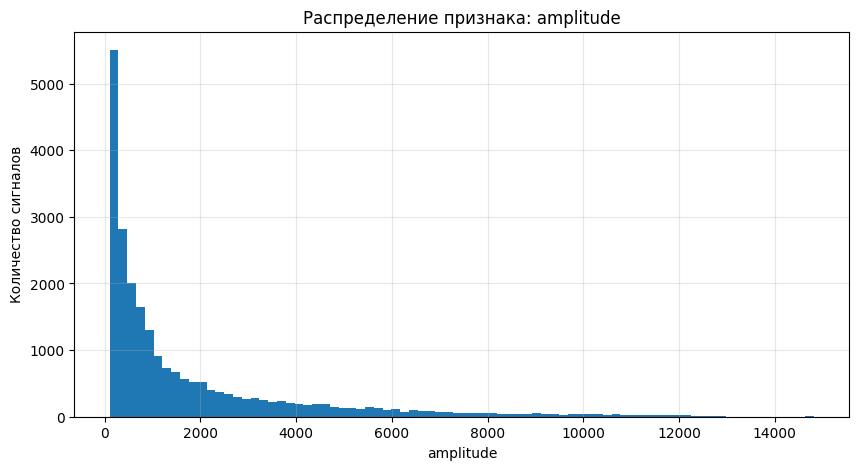

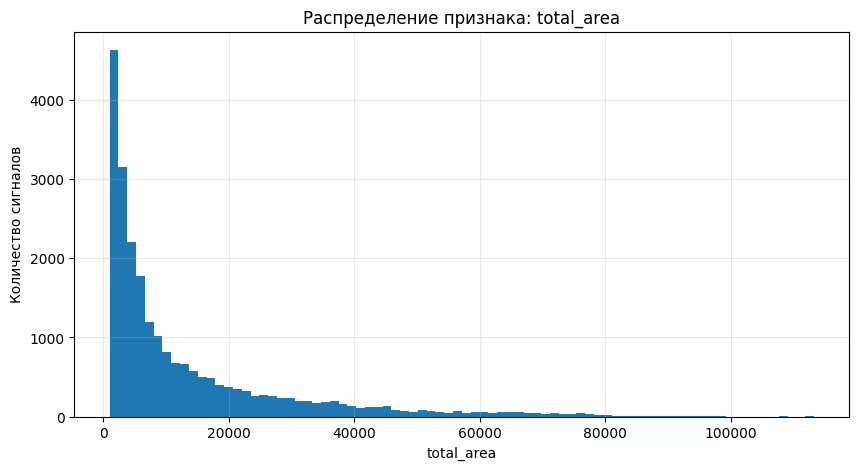

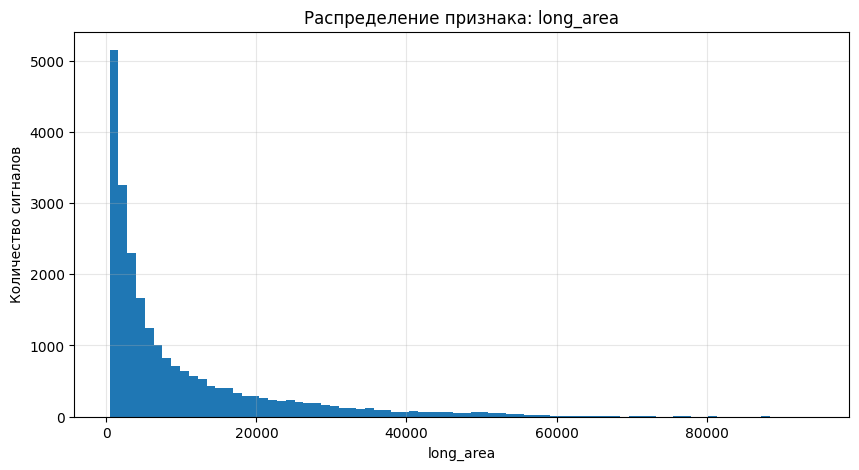

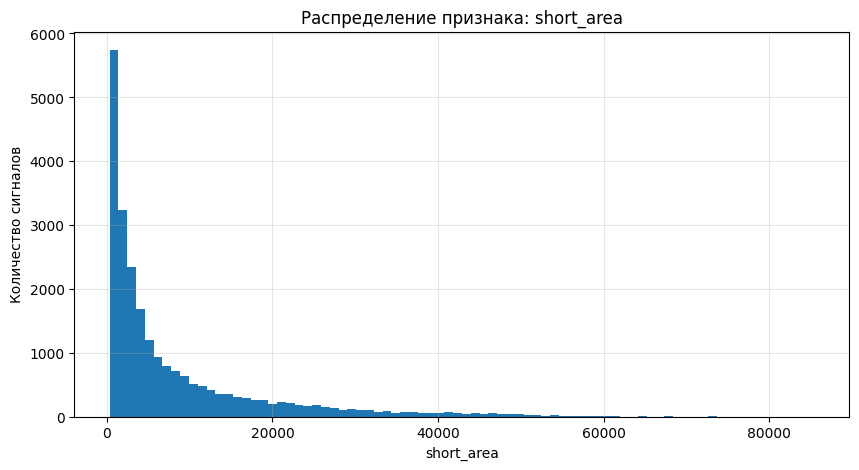

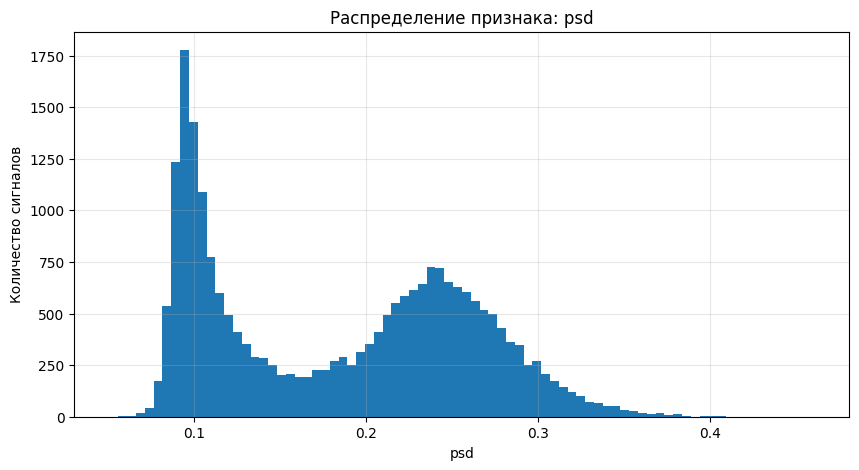

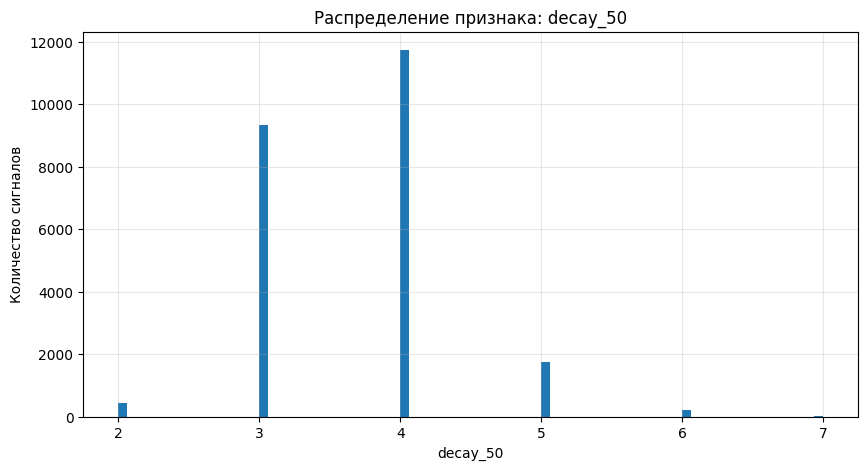

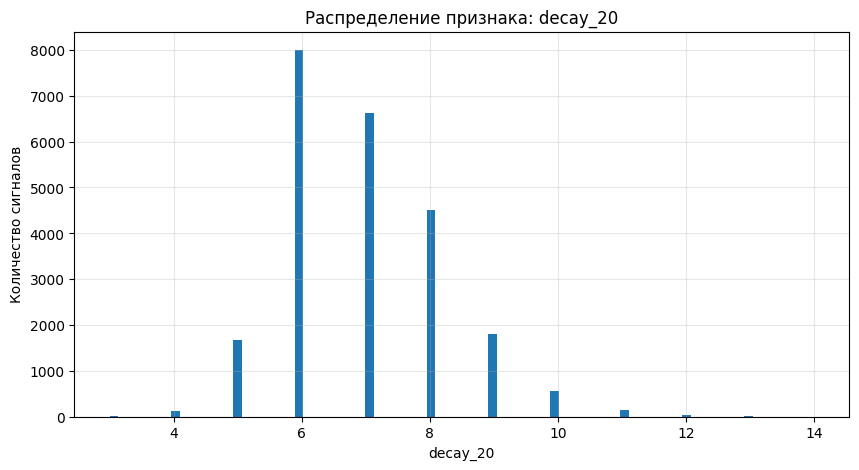

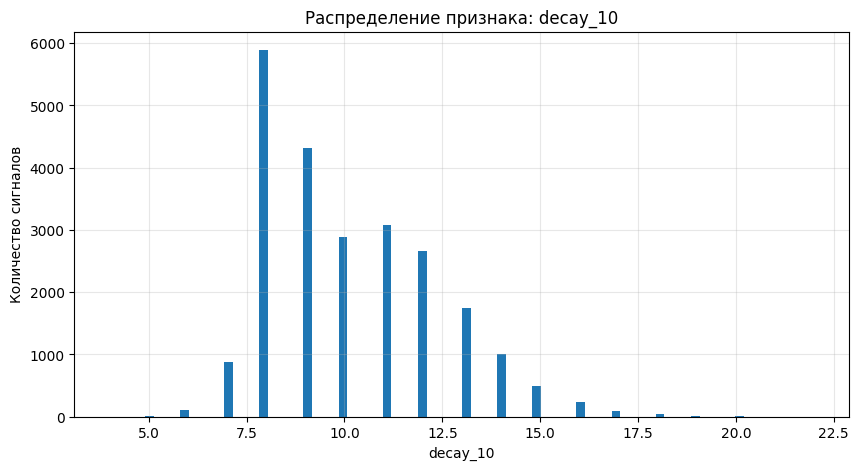

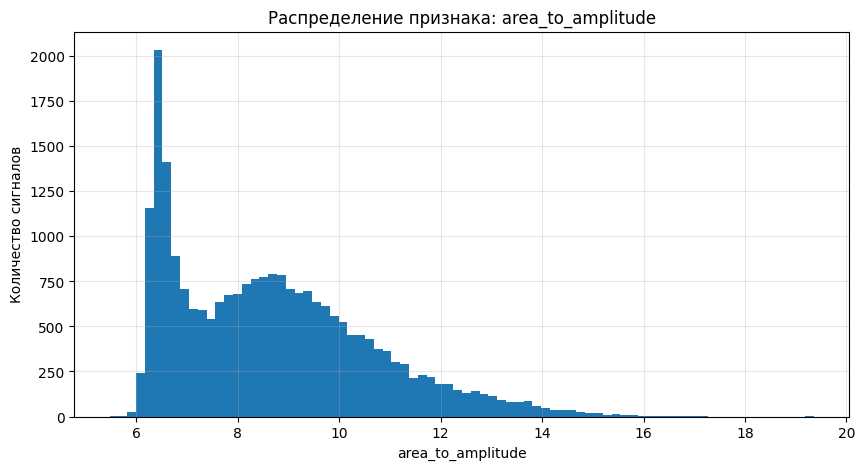

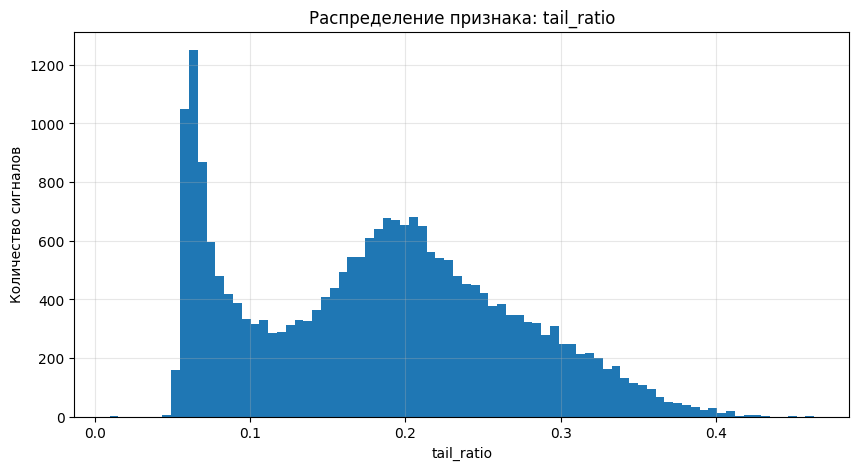

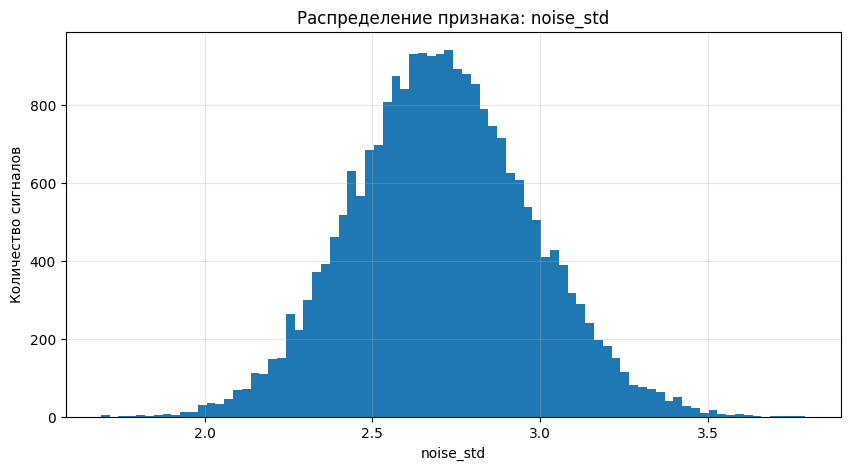

In [21]:
main_features = [
    "amplitude",
    "total_area",
    "long_area",
    "short_area",
    "psd",
    "decay_50",
    "decay_20",
    "decay_10",
    "area_to_amplitude",
    "tail_ratio",
    "noise_std"
]

for col in main_features:
    plt.figure(figsize=(10, 5))
    plt.hist(features[col], bins=80)
    plt.title(f"Распределение признака: {col}")
    plt.xlabel(col)
    plt.ylabel("Количество сигналов")
    plt.grid(alpha=0.3)
    plt.show()

После формирования признакового пространства был выполнен анализ распределений основных признаков с использованием гистограмм. Цель данного этапа заключалась в оценке структуры данных, выявлении возможных выбросов, определении характера распределений и проверке пригодности признаков для последующей кластеризации.

Для каждого признака была построена гистограмма распределения значений по всей выборке сигналов.

Результаты анализа показали, что признаки amplitude, total_area, short_area и long_area обладают выраженной правосторонней асимметрией. Для большинства сигналов характерны относительно небольшие значения амплитуды и площади, однако присутствует небольшая группа импульсов с существенно большими значениями. Подобное распределение является типичным для сцинтилляционных сигналов и свидетельствует о наличии событий различной интенсивности.

Признак psd демонстрирует многомодальную структуру распределения. Наличие нескольких выраженных максимумов указывает на существование различных групп сигналов, отличающихся по соотношению быстрой и медленной компонент импульса. Данный результат косвенно подтверждает возможность выделения нескольких кластеров по форме сигнала.

Распределения признаков decay_50, decay_20 и decay_10 имеют дискретный характер. Это связано с тем, что время спада измеряется в целых временных отсчётах. Основная масса наблюдений сосредоточена в относительно узком диапазоне значений, что свидетельствует о схожем характере затухания большинства импульсов.

Признак area_to_amplitude имеет асимметричное распределение с выраженной концентрацией наблюдений в диапазоне средних значений. Данный показатель отражает относительную ширину импульса и позволяет различать узкие и широкие сигналы.

Признак tail_ratio характеризуется наличием нескольких локальных максимумов и достаточно широким диапазоном значений. Это свидетельствует о различиях в выраженности хвостовой части сигналов и указывает на его потенциальную информативность для задач кластеризации.

В отличие от большинства физических характеристик, признак noise_std имеет распределение, близкое к нормальному. Это говорит о стабильном уровне фонового шума в исследуемой выборке и отсутствии значительного количества аномальных наблюдений.

В целом проведённый анализ показал, что сформированные признаки обладают различной структурой распределений и содержат информацию о различных аспектах формы сцинтилляционных импульсов. Особенно информативными для последующей кластеризации представляются признаки, связанные с формой и затуханием сигнала (psd, tail_ratio, decay_50, decay_20, decay_10), поскольку они демонстрируют наличие нескольких характерных групп наблюдений внутри выборки.

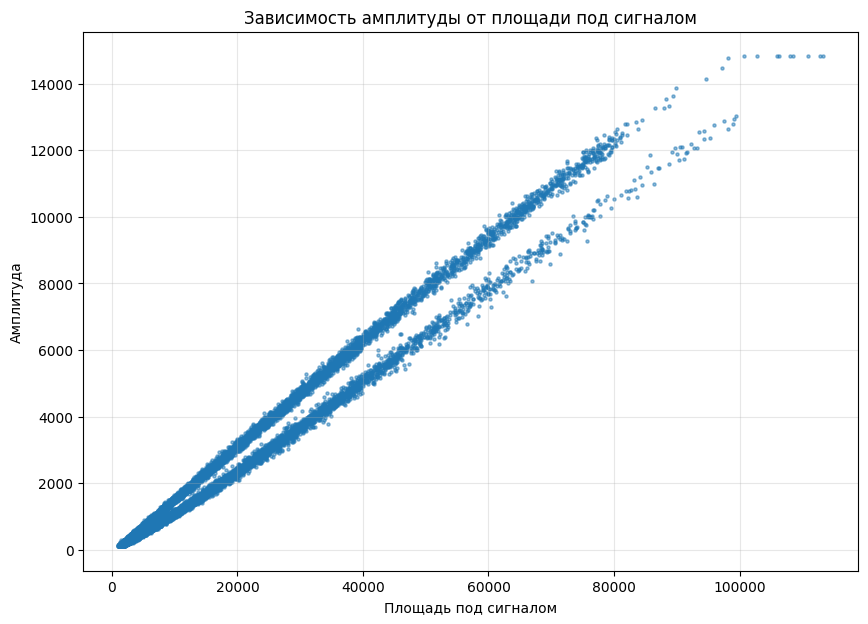

In [22]:
plt.figure(figsize=(10, 7))
plt.scatter(
    features["total_area"],
    features["amplitude"],
    s=5,
    alpha=0.5
)
plt.title("Зависимость амплитуды от площади под сигналом")
plt.xlabel("Площадь под сигналом")
plt.ylabel("Амплитуда")
plt.grid(alpha=0.3)
plt.show()

Для оценки взаимосвязи между основными энергетическими характеристиками импульсов была построена диаграмма рассеяния, отображающая зависимость максимальной амплитуды сигнала от его полной площади.

Полученный график демонстрирует выраженную положительную зависимость между рассматриваемыми признаками. С увеличением площади под сигналом наблюдается закономерный рост амплитуды импульса. Это свидетельствует о том, что оба признака описывают близкие физические свойства зарегистрированных событий и характеризуют интенсивность сигнала.

Вместе с тем зависимость не является строго линейной. На графике отчётливо наблюдаются несколько отдельных полос (ветвей) распределения точек. Наличие таких структур указывает на существование различных типов сигналов, имеющих сходную площадь, но отличающихся формой импульса. Вероятно, данные группы связаны с различиями во времени затухания или соотношении быстрой и медленной компонент сигнала.

Также можно отметить отсутствие большого количества изолированных выбросов. Большинство наблюдений формируют компактные области высокой плотности, что свидетельствует о хорошем качестве данных после проведённой предобработки.

Полученный результат подтверждает наличие сильной корреляционной связи между признаками amplitude и total_area. Следовательно, данные признаки частично дублируют информацию друг друга и могут рассматриваться как взаимосвязанные характеристики энергетических параметров импульса. Одновременно наличие нескольких выраженных ветвей распределения свидетельствует о скрытой структуре данных и косвенно подтверждает возможность успешного применения методов кластеризации для разделения сигналов по форме.

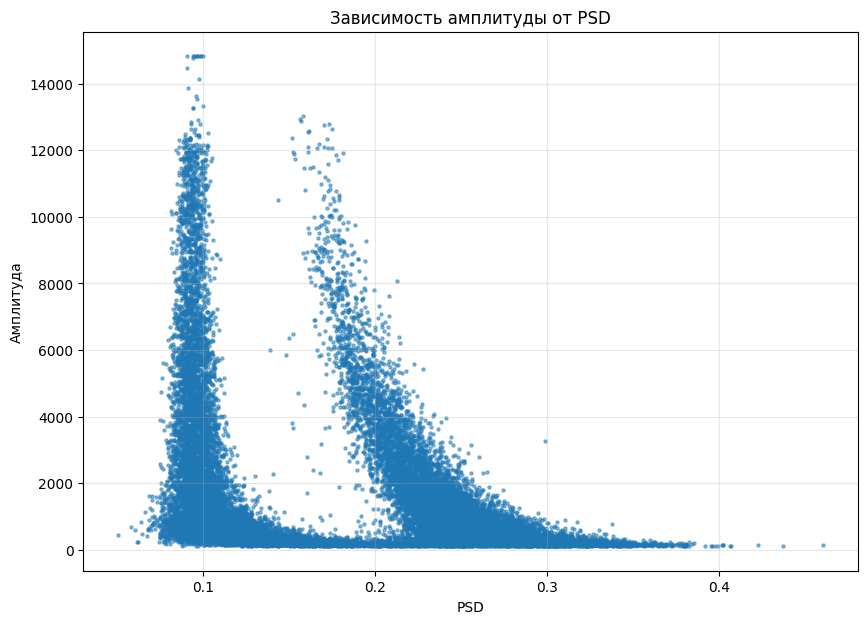

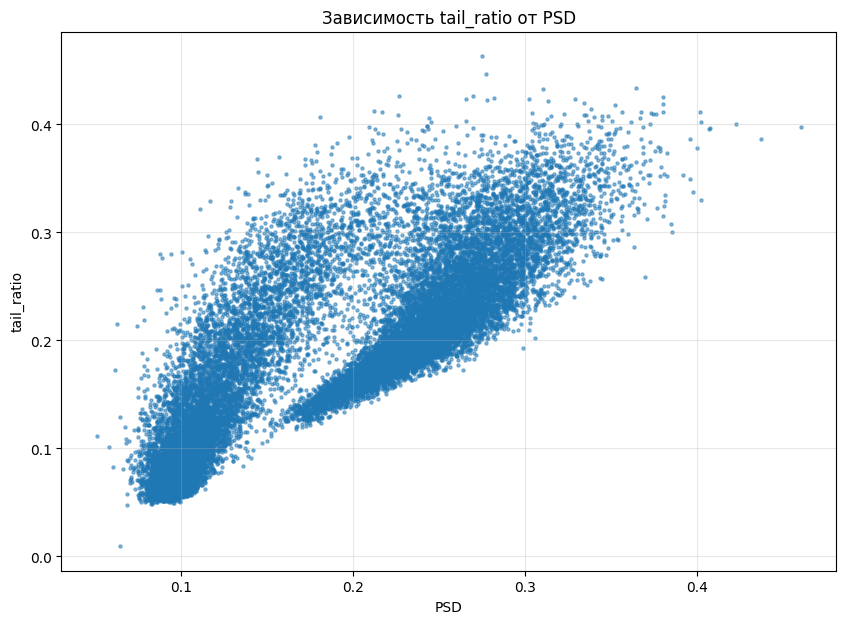

In [23]:
plt.figure(figsize=(10, 7))
plt.scatter(
    features["psd"],
    features["amplitude"],
    s=5,
    alpha=0.5
)
plt.title("Зависимость амплитуды от PSD")
plt.xlabel("PSD")
plt.ylabel("Амплитуда")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 7))
plt.scatter(
    features["psd"],
    features["tail_ratio"],
    s=5,
    alpha=0.5
)
plt.title("Зависимость tail_ratio от PSD")
plt.xlabel("PSD")
plt.ylabel("tail_ratio")
plt.grid(alpha=0.3)
plt.show()

Для исследования взаимосвязи между амплитудой импульса и параметром PSD (Pulse Shape Discrimination) была построена диаграмма рассеяния, отображающая распределение сигналов в пространстве данных признаков.

Полученный график показывает отсутствие простой линейной зависимости между амплитудой сигнала и значением PSD. В отличие от зависимости между амплитудой и площадью импульса, точки формируют несколько выраженных областей концентрации, что свидетельствует о наличии различных групп сигналов с отличающейся формой импульса.

Особенно заметны две основные области повышенной плотности наблюдений, расположенные примерно в диапазонах PSD около 0,10 и 0,20–0,25. Такая структура распределения указывает на существование нескольких типов импульсов, различающихся по соотношению быстрой и медленной компонент сигнала.

Также можно отметить, что максимальные значения амплитуды встречаются преимущественно в ограниченном диапазоне значений PSD. При увеличении показателя PSD наблюдается тенденция к уменьшению максимальной амплитуды регистрируемых сигналов, что может быть связано с изменением формы импульса и увеличением вклада его хвостовой части.

Дополнительно следует отметить наличие выраженной неоднородности распределения точек. Вместо единого непрерывного облака наблюдаются отдельные скопления объектов, разделённые областями меньшей плотности. Подобная картина является важным признаком существования скрытой кластерной структуры в данных.

Полученные результаты свидетельствуют о том, что признак PSD содержит информацию, отличную от амплитудных характеристик сигнала, и способен эффективно разделять импульсы по их форме. Наличие нескольких устойчивых областей концентрации наблюдений подтверждает высокую информативность данного признака для последующей задачи кластеризации сцинтилляционных сигналов.

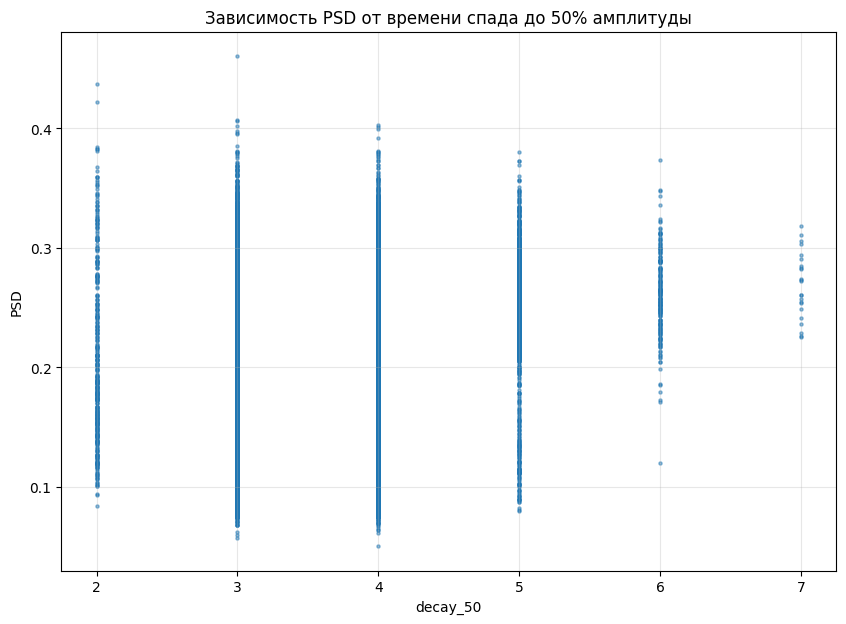

In [24]:
plt.figure(figsize=(10, 7))
plt.scatter(
    features["decay_50"],
    features["psd"],
    s=5,
    alpha=0.5
)
plt.title("Зависимость PSD от времени спада до 50% амплитуды")
plt.xlabel("decay_50")
plt.ylabel("PSD")
plt.grid(alpha=0.3)
plt.show()

Для исследования связи между формой импульса и скоростью его затухания была построена диаграмма рассеяния, отображающая зависимость показателя PSD от времени спада сигнала до уровня 50 % от максимальной амплитуды.

Поскольку признак decay_50 измеряется в целых временных отсчётах, на графике наблюдаются вертикальные группы точек, соответствующие отдельным значениям времени спада. Основная часть сигналов имеет время спада от 3 до 5 отсчётов, что указывает на относительно близкие характеристики затухания для большинства зарегистрированных импульсов.

При этом для каждого значения decay_50 наблюдается широкий диапазон значений PSD. Это свидетельствует о том, что скорость уменьшения амплитуды до уровня 50 % не определяет полностью структуру сигнала и не позволяет однозначно описать соотношение быстрой и медленной компонент импульса.

Одновременно можно заметить определённую тенденцию к увеличению средних значений PSD при росте времени спада. Сигналы с более длительным затуханием, как правило, характеризуются более выраженной хвостовой частью и, соответственно, большими значениями показателя PSD. Такой результат согласуется с физическим смыслом рассматриваемых признаков.

#### Масштабирование признаков

In [25]:
X_features = features.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

print("Размерность масштабированной матрицы:", X_scaled.shape)

Размерность масштабированной матрицы: (23479, 14)


In [26]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PCA_1": X_pca[:, 0],
    "PCA_2": X_pca[:, 1]
})

print("Доля объяснённой дисперсии:")
print(pca.explained_variance_ratio_)
print("Суммарно:", pca.explained_variance_ratio_.sum())

display(pca_df.head())

Доля объяснённой дисперсии:
[0.44297084 0.21409111]
Суммарно: 0.6570619521017396


,PCA_1,PCA_2
0,-1.810991,0.396854
1,1.004197,-1.020083
2,1.862911,-1.795801
3,-1.375541,0.048409
4,1.078913,-1.401695


Для визуального анализа структуры данных было выполнено преобразование признакового пространства методом главных компонент (PCA). Поскольку исходный набор содержал 14 признаков, непосредственная визуализация объектов затруднена. Метод PCA позволил спроецировать данные в двумерное пространство, образованное двумя главными компонентами, сохраняющими наибольшую долю изменчивости исходных данных.

Первая главная компонента объясняет 40,56 % общей дисперсии, а вторая — 21,4 %. Суммарно две компоненты сохраняют 65,71 % информации исходного признакового пространства. Полученное двумерное представление использовалось для визуального анализа распределения сигналов и последующего отображения результатов кластеризации.

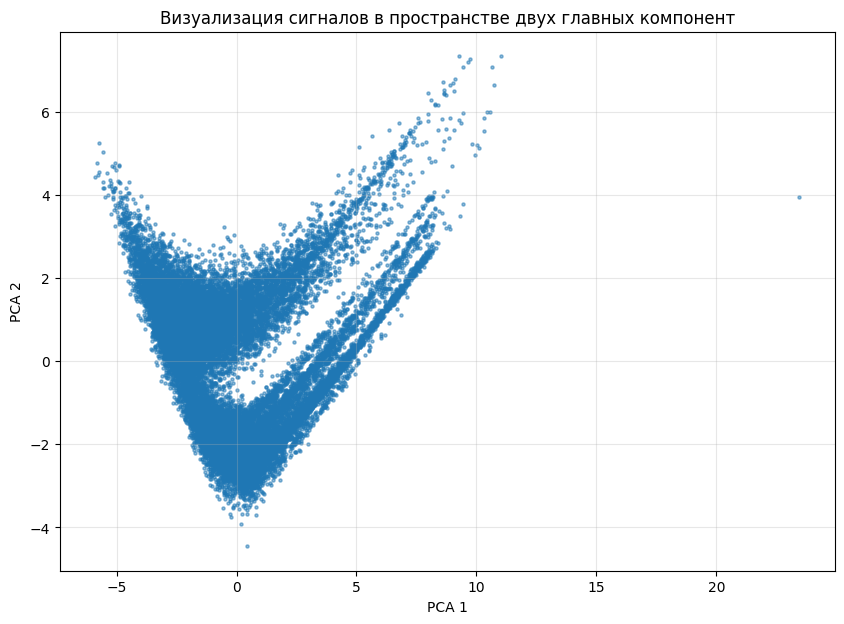

In [27]:
plt.figure(figsize=(10, 7))
plt.scatter(
    pca_df["PCA_1"],
    pca_df["PCA_2"],
    s=5,
    alpha=0.5
)
plt.title("Визуализация сигналов в пространстве двух главных компонент")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(alpha=0.3)
plt.show()

Метод главных компонент был использован для визуализации сигналов в двумерном пространстве. Это позволяет предварительно оценить, существуют ли в данных естественные группы. Если на графике видны отдельные облака точек или вытянутые структуры, это указывает на возможность дальнейшей кластеризации.

In [28]:
pca = PCA(
    n_components=0.95,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

print("Исходное число признаков:", X_scaled.shape[1])
print("Число компонент после PCA:", X_pca.shape[1])
print("Сохранённая дисперсия:",
      pca.explained_variance_ratio_.sum())
# удобно
X_scaled = (X_pca)

Исходное число признаков: 14
Число компонент после PCA: 7
Сохранённая дисперсия: 0.9545319029545102


### Обучение нескольких моделей, их сравнение, подбор гиперпараметров

In [29]:
results = {}
labels_dict = {}
models_dict = {}

#### Модель KMeans

Реализуется процедура выбора оптимальной конфигурации алгоритма кластеризации KMeans путём перебора гиперпараметров

In [30]:
best_score = -1
best_model = None
best_labels = None
best_params = None

param_grid = {
    "n_clusters": [3],
    "n_init": [20],
    "max_iter": [1000, 1500],
    "algorithm": ["lloyd", "elkan"]
}

for (
    n_clusters,
    n_init,
    max_iter,
    algorithm
) in itertools.product(
    param_grid["n_clusters"],
    param_grid["n_init"],
    param_grid["max_iter"],
    param_grid["algorithm"]
):

    model = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=n_init,
        max_iter=max_iter,
        algorithm=algorithm
    )

    labels = model.fit_predict(X_scaled)

    if len(np.unique(labels)) < 2:
        continue

    silhouette = silhouette_score(
        X_scaled,
        labels,
        sample_size=min(23479, X_scaled.shape[0]),
        random_state=42
    )

    if silhouette > best_score:
        best_score = silhouette
        best_model = model
        best_labels = labels

        best_params = {
            "n_clusters": n_clusters,
            "n_init": n_init,
            "max_iter": max_iter,
            "algorithm": algorithm
        }

print("Лучшие параметры:")
print(best_params)

print("Лучший silhouette:")
print(best_score)

calinski = calinski_harabasz_score(
    X_scaled,
    best_labels
)

davies = davies_bouldin_score(
    X_scaled,
    best_labels
)

cluster_counts = (
    pd.Series(best_labels)
    .value_counts()
    .sort_index()
)

model_name = "KMeans_Best"

results[model_name] = {
    "model": model_name,
    "n_clusters": len(np.unique(best_labels)),
    "silhouette": best_score,
    "calinski_harabasz": calinski,
    "davies_bouldin": davies,
    "best_params": str(best_params),
    "cluster_0_count": cluster_counts.get(0, 0),
    "cluster_1_count": cluster_counts.get(1, 0),
    "cluster_2_count": cluster_counts.get(2, 0)
}

labels_dict[model_name] = best_labels
models_dict[model_name] = best_model

features["cluster_kmeans"] = best_labels
pca_df["cluster_kmeans"] = best_labels


Лучшие параметры:
{'n_clusters': 3, 'n_init': 20, 'max_iter': 1000, 'algorithm': 'lloyd'}
Лучший silhouette:
0.3106935989903894


#### Модель MiniBatchKMeans

Реализуется процедура выбора оптимальной конфигурации алгоритма кластеризации MiniBatchKMeans путём перебора гиперпараметров

In [31]:

param_grid = {
    "n_clusters": [3],
    "batch_size": [2048],
    "n_init": [500, 100, 1500],
    "max_iter": [1000, 500,1500],
    "init": ["k-means++", "random"]
}

best_score = -1.0
best_model = None
best_labels = None
best_params = None

# Генерируем все комбинации
combinations = list(itertools.product(
    param_grid["n_clusters"],
    param_grid["batch_size"],
    param_grid["n_init"],
    param_grid["max_iter"],
    param_grid["init"]                  # 
))

print(f"Всего комбинаций для проверки: {len(combinations)}\n")

# for n_clusters, batch_size, n_init, max_iter, init, reassignment_ratio in tqdm(combinations): # С tqdm
for n_clusters, batch_size, n_init, max_iter, init in combinations:

    model = MiniBatchKMeans(
        n_clusters=n_clusters,
        random_state=42,
        batch_size=batch_size,
        n_init=n_init,
        init=init,
        max_iter=max_iter
    )

    labels = model.fit_predict(X_scaled)

    
    if len(np.unique(labels)) < 2:
        continue

    silhouette = silhouette_score(
        X_scaled,
        labels,
        sample_size=min(30000, X_scaled.shape[0]), # 
        random_state=42
    )

    if silhouette > best_score:
        best_score = silhouette
        best_model = model
        best_labels = labels
        
        
        best_params = {
            "n_clusters": n_clusters,
            "batch_size": batch_size,
            "n_init": n_init,
            "max_iter": max_iter,
            "init": init 
        }
        print(f"Найден новый лучший результат: Silhouette = {best_score:.4f} при params = {best_params}")

print("\n--- Результаты поиска ---")
print("Лучшие параметры:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"Лучший Silhouette score для MiniBatchKMeans_Best: {best_score:.4f}")

# Пересчитываем остальные метрики для лучшей модели на полных данных (без sample_size)
calinski = calinski_harabasz_score(X_scaled, best_labels)
davies = davies_bouldin_score(X_scaled, best_labels)

cluster_counts = (
    pd.Series(best_labels)
    .value_counts()
    .sort_index()
)

model_name = "MiniBatchKMeans_Best"

results[model_name] = {
    "model": model_name,
    "n_clusters": len(np.unique(best_labels)),
    "silhouette": best_score,
    "calinski_harabasz": calinski,
    "davies_bouldin": davies,
    "best_params": best_params,
    **{
        f"cluster_{i}_count": int(cluster_counts.get(i, 0))
        for i in range(len(np.unique(best_labels)))
    }
}

labels_dict[model_name] = best_labels
models_dict[model_name] = best_model

features["cluster_mini_batch_kmeans"] = best_labels
pca_df["cluster_mini_batch_kmeans"] = best_labels

display(pd.DataFrame(results).T)

Всего комбинаций для проверки: 18

Найден новый лучший результат: Silhouette = 0.3110 при params = {'n_clusters': 3, 'batch_size': 2048, 'n_init': 500, 'max_iter': 1000, 'init': 'k-means++'}

--- Результаты поиска ---
Лучшие параметры:
  n_clusters: 3
  batch_size: 2048
  n_init: 500
  max_iter: 1000
  init: k-means++
Лучший Silhouette score для MiniBatchKMeans_Best: 0.3110


,model,n_clusters,silhouette,calinski_harabasz,davies_bouldin,best_params,cluster_0_count,cluster_1_count,cluster_2_count
KMeans_Best,KMeans_Best,3,0.310694,11261.768025,1.157185,"{'n_clusters': 3, 'n_init': 20, 'max_iter': 10...",10617,8868,3994
MiniBatchKMeans_Best,MiniBatchKMeans_Best,3,0.311026,11257.577809,1.157067,"{'n_clusters': 3, 'batch_size': 2048, 'n_init'...",3861,10680,8938


#### Модель GaussianMixture

In [32]:
best_score = -1
best_model = None
best_labels = None
best_params = None

param_grid = {
    "n_components": [3],
    "covariance_type": ["full", "diag"],
    "reg_covar": [1e-6, 1e-5, 1e-4, 1e-3],
    "n_init": [5, 10],
    "max_iter": [300, 1000]
}

for (
    n_components,
    covariance_type,           
    reg_covar,
    n_init,
    max_iter
) in itertools.product(
    param_grid["n_components"],
    param_grid["covariance_type"],
    param_grid["reg_covar"],
    param_grid["n_init"],
    param_grid["max_iter"]
):

    model = GaussianMixture(
        n_components=n_components,
        covariance_type=covariance_type,
        reg_covar=reg_covar,
        n_init=n_init,
        max_iter=max_iter,
        random_state=42
    )

    labels = model.fit_predict(X_scaled)

    if len(np.unique(labels)) < 2:
        continue

    silhouette = silhouette_score(
        X_scaled,
        labels,
        sample_size=min(23479, X_scaled.shape[0]),
        random_state=42
    )

    if silhouette > best_score:
        best_score = silhouette
        best_model = model
        best_labels = labels

        best_params = {
            "n_components": n_components,
            "covariance_type": covariance_type,
            "reg_covar": reg_covar,
            "n_init": n_init,
            "max_iter": max_iter
        }

print("Лучшие параметры:")
print(best_params)
print("Лучший silhouette:", best_score)

calinski = calinski_harabasz_score(
    X_scaled,
    best_labels
)

davies = davies_bouldin_score(
    X_scaled,
    best_labels
)

cluster_counts = (
    pd.Series(best_labels)
    .value_counts()
    .sort_index()
)

model_name = "GMM_Best"

results[model_name] = {
    "model": model_name,
    "n_clusters": len(np.unique(best_labels)),
    "silhouette": best_score,
    "calinski_harabasz": calinski,
    "davies_bouldin": davies,
    "best_params": best_params,
    **{
        f"cluster_{i}_count": cluster_counts.get(i, 0)
        for i in range(len(np.unique(best_labels)))
    }
}

labels_dict[model_name] = best_labels
models_dict[model_name] = best_model

features["cluster_gmm"] = best_labels
pca_df["cluster_gmm"] = best_labels

display(pd.DataFrame(results).T)

Лучшие параметры:
{'n_components': 3, 'covariance_type': 'full', 'reg_covar': 0.001, 'n_init': 5, 'max_iter': 300}
Лучший silhouette: 0.28434410400389726


,model,n_clusters,silhouette,calinski_harabasz,davies_bouldin,best_params,cluster_0_count,cluster_1_count,cluster_2_count
KMeans_Best,KMeans_Best,3,0.310694,11261.768025,1.157185,"{'n_clusters': 3, 'n_init': 20, 'max_iter': 10...",10617,8868,3994
MiniBatchKMeans_Best,MiniBatchKMeans_Best,3,0.311026,11257.577809,1.157067,"{'n_clusters': 3, 'batch_size': 2048, 'n_init'...",3861,10680,8938
GMM_Best,GMM_Best,3,0.284344,10338.555365,1.211689,"{'n_components': 3, 'covariance_type': 'full',...",9839,7994,5646


Сравнение моделей

In [33]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

results_df = pd.DataFrame(results).T.reset_index(drop=True)

results_df = results_df.sort_values(
    by=["silhouette", "calinski_harabasz", "davies_bouldin"],
    ascending=[False, False, True]
)

print("Количество моделей:", len(results_df))
print()

display(results_df)

Количество моделей: 3



,model,n_clusters,silhouette,calinski_harabasz,davies_bouldin,best_params,cluster_0_count,cluster_1_count,cluster_2_count
1,MiniBatchKMeans_Best,3,0.311026,11257.577809,1.157067,"{'n_clusters': 3, 'batch_size': 2048, 'n_init': 500, 'max_iter': 1000, 'init': 'k-means++'}",3861,10680,8938
0,KMeans_Best,3,0.310694,11261.768025,1.157185,"{'n_clusters': 3, 'n_init': 20, 'max_iter': 1000, 'algorithm': 'lloyd'}",10617,8868,3994
2,GMM_Best,3,0.284344,10338.555365,1.211689,"{'n_components': 3, 'covariance_type': 'full', 'reg_covar': 0.001, 'n_init': 5, 'max_iter': 300}",9839,7994,5646


🏆 Лучшая модель: MiniBatchKMeans_Best
Silhouette: 0.3110

📊 Важность PCA-компонент для кластеризации:


,component,importance
0,PC1,2.477797
1,PC2,1.477148
2,PC5,0.202279
3,PC6,0.119199
4,PC7,0.068624
5,PC3,0.033690
6,PC4,0.010757


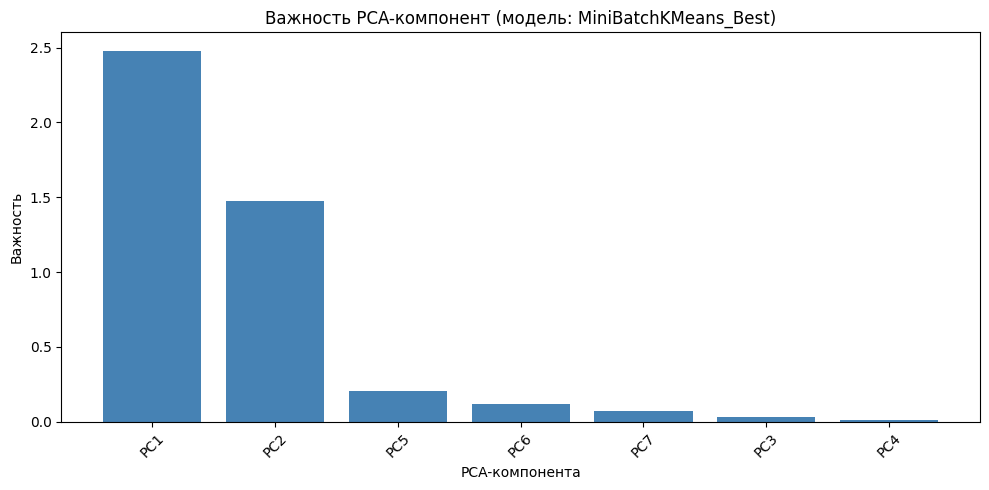

📊 Важность ИСХОДНЫХ признаков (через PCA loadings):


,feature,importance
0,long_area,0.290312
1,total_area,0.289574
2,short_area,0.285282
3,amplitude,0.279185
4,area_to_amplitude,0.278285
5,psd,0.278046
6,tail_area_after_20,0.269164
7,decay_10,0.261650
8,decay_20,0.256429
9,tail_ratio,0.255619


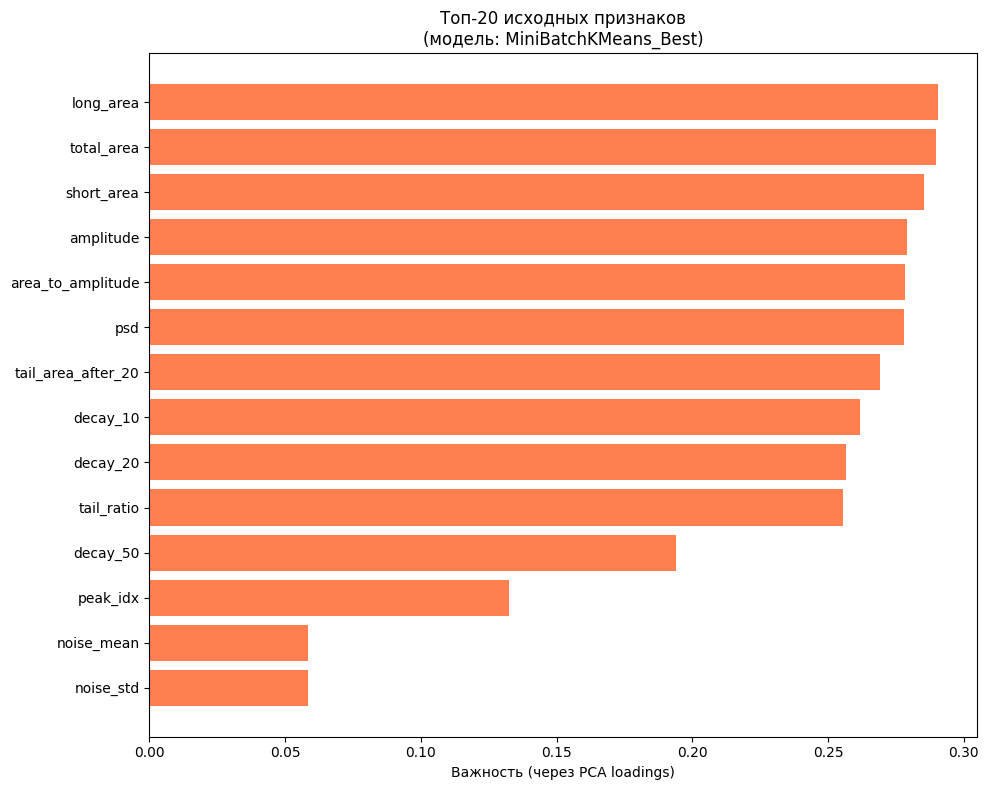


📊 Проверочный метод: Random Forest на кластерах


,component,importance
0,PC2,0.468933
1,PC1,0.410257
2,PC5,0.043012
3,PC6,0.042404
4,PC7,0.030023
5,PC3,0.003361
6,PC4,0.002010



📊 Важность исходных признаков (RF через PCA loadings):


,feature,importance
0,psd,0.280137
1,long_area,0.276587
2,total_area,0.275618
3,tail_area_after_20,0.275151
4,decay_10,0.271989
5,area_to_amplitude,0.269965
6,short_area,0.269233
7,decay_20,0.269114
8,amplitude,0.260917
9,tail_ratio,0.241534



🏆 СВОДНЫЙ ТОП-15 ИСХОДНЫХ ПРИЗНАКОВ:


,feature,ANOVA_via_PCA,RF_via_PCA,avg_importance
0,long_area,0.290312,0.276587,0.283449
1,total_area,0.289574,0.275618,0.282596
2,psd,0.278046,0.280137,0.279091
3,short_area,0.285282,0.269233,0.277258
4,area_to_amplitude,0.278285,0.269965,0.274125
5,tail_area_after_20,0.269164,0.275151,0.272157
6,amplitude,0.279185,0.260917,0.270051
7,decay_10,0.261650,0.271989,0.266820
8,decay_20,0.256429,0.269114,0.262771
9,tail_ratio,0.255619,0.241534,0.248577


In [34]:

best_model_name = max(results.keys(), key=lambda k: results[k]['silhouette'])
best_model = models_dict[best_model_name]
best_labels = labels_dict[best_model_name]

print(f"🏆 Лучшая модель: {best_model_name}")
print(f"Silhouette: {results[best_model_name]['silhouette']:.4f}\n")


# 2. Важность PCA-компонент (какие компоненты важны для кластеров)

n_components = X_scaled.shape[1]
component_names = [f'PC{i+1}' for i in range(n_components)]

# Метод A: Разброс центроидов по компонентам (для KMeans)
if isinstance(best_model, (KMeans, MiniBatchKMeans)):
    centers = best_model.cluster_centers_
    pc_importance = pd.DataFrame({
        'component': component_names,
        'importance': np.std(centers, axis=0)
    })
# Метод B: ANOVA F-score по компонентам (универсальный)
else:
    f_scores, _ = f_classif(X_scaled, best_labels)
    pc_importance = pd.DataFrame({
        'component': component_names,
        'importance': f_scores
    })

pc_importance = pc_importance.sort_values('importance', ascending=False).reset_index(drop=True)

print("📊 Важность PCA-компонент для кластеризации:")
display(pc_importance.head(10))

plt.figure(figsize=(10, 5))
plt.bar(pc_importance['component'], pc_importance['importance'], color='steelblue')
plt.xlabel('PCA-компонента')
plt.ylabel('Важность')
plt.title(f'Важность PCA-компонент (модель: {best_model_name})')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# loadings: каждая строка — компонента, каждый столбец — исходный признак
loadings = pca.components_.T  # форма: (n_features, n_components)

# Берем имена исходных признаков из оригинального DataFrame features
if hasattr(features, 'columns'):
    original_features = [c for c in features.columns if c != 'cluster_kmeans' 
                         and 'cluster_' not in c]
    # Если original_features не совпадает по длине с loadings, берем все числовые
    if len(original_features) != loadings.shape[0]:
        original_features = [f'feature_{i}' for i in range(loadings.shape[0])]
else:
    original_features = [f'feature_{i}' for i in range(loadings.shape[0])]

# Важность каждого исходного признака = сумма |loading| * важность компоненты
# (признак важен, если он сильно загружен в важные компоненты)
feature_importance_original = np.zeros(loadings.shape[0])
for i, imp in enumerate(pc_importance['importance'].values):
    # нормализуем важность компоненты
    norm_imp = imp / pc_importance['importance'].sum()
    # вклад признака = |loading| * норм.важность компоненты
    feature_importance_original += np.abs(loadings[:, i]) * norm_imp

original_importance_df = pd.DataFrame({
    'feature': original_features,
    'importance': feature_importance_original
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("📊 Важность ИСХОДНЫХ признаков (через PCA loadings):")
display(original_importance_df.head(20))

# Визуализация топ-20 исходных признаков
plt.figure(figsize=(10, 8))
top = original_importance_df.head(20)
plt.barh(top['feature'][::-1], top['importance'][::-1], color='coral')
plt.xlabel('Важность (через PCA loadings)')
plt.title(f'Топ-20 исходных признаков\n(модель: {best_model_name})')
plt.tight_layout()
plt.show()


print("\n" + "="*60)
print("📊 Проверочный метод: Random Forest на кластерах")
print("="*60)

clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
clf.fit(X_scaled, best_labels)

rf_pc_importance = pd.DataFrame({
    'component': component_names,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

display(rf_pc_importance.head(10))

# RF-важность исходных признаков через loadings
rf_feature_importance = np.zeros(loadings.shape[0])
for i, imp in enumerate(rf_pc_importance['importance'].values):
    rf_feature_importance += np.abs(loadings[:, i]) * imp

rf_original_df = pd.DataFrame({
    'feature': original_features,
    'importance': rf_feature_importance
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\n📊 Важность исходных признаков (RF через PCA loadings):")
display(rf_original_df.head(20))


summary = original_importance_df[['feature', 'importance']].rename(columns={'importance': 'ANOVA_via_PCA'})
summary = summary.merge(
    rf_original_df[['feature', 'importance']].rename(columns={'importance': 'RF_via_PCA'}),
    on='feature'
)
summary['avg_importance'] = summary[['ANOVA_via_PCA', 'RF_via_PCA']].mean(axis=1)
summary = summary.sort_values('avg_importance', ascending=False).reset_index(drop=True)

print("\n🏆 СВОДНЫЙ ТОП-15 ИСХОДНЫХ ПРИЗНАКОВ:")
display(summary.head(15))

### submission

In [35]:
# Выбираем лучшую модель по silhouette

best_model_name = max(
    results,
    key=lambda x: results[x]["silhouette"]
)

best_labels = labels_dict[best_model_name]

print("Используется лучшая модель:", best_model_name)
print("Silhouette:", results[best_model_name]["silhouette"])

old_labels = pd.Series(best_labels)

print("Количество меток:", len(old_labels))
print("Уникальные старые метки:")
print(sorted(old_labels.unique()))



unique_labels_in_order = (
    old_labels
    .drop_duplicates()
    .tolist()
)

label_map = {
    old_label: new_label
    for new_label, old_label in enumerate(
        unique_labels_in_order
    )
}

print("Преобразование меток:")
print(label_map)

new_labels = old_labels.map(label_map).astype(int)

submission = pd.DataFrame({
    "index": np.arange(len(new_labels)),
    "cluster": new_labels
})

submission.to_csv(
    "submission.csv",
    index=False
)

print("submission.csv saved")

display(submission.head())

print("Уникальные cluster после преобразования:")
print(sorted(submission["cluster"].unique()))

print("Распределение кластеров:")
display(
    submission["cluster"]
    .value_counts()
    .sort_index()
    .to_frame("count")
    .assign(
        percent=lambda x: (
            x["count"]
            / x["count"].sum()
            * 100
        ).round(2)
    )
)


print("\nРазмер submission:")
print(submission.shape)

Используется лучшая модель: MiniBatchKMeans_Best
Silhouette: 0.3110260632216924
Количество меток: 23479
Уникальные старые метки:
[np.int32(0), np.int32(1), np.int32(2)]
Преобразование меток:
{1: 0, 2: 1, 0: 2}
submission.csv saved


,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1


Уникальные cluster после преобразования:
[np.int64(0), np.int64(1), np.int64(2)]
Распределение кластеров:


,count,percent
cluster,,
0,10680,45.49
1,8938,38.07
2,3861,16.44



Размер submission:
(23479, 2)


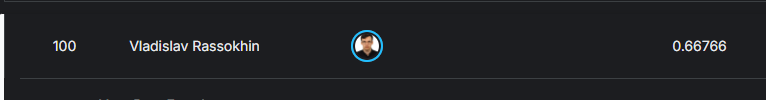

Попробуем улучшить качество модели удалив не значимые признаки

In [36]:
X_features = features.copy()
X_X=X_features
# Порог: оставляем признаки, дающие 95% суммарной важности
threshold = 0.95
sorted_imp = summary.sort_values('avg_importance', ascending=False)
sorted_imp['cumulative'] = sorted_imp['avg_importance'].cumsum() / sorted_imp['avg_importance'].sum()

features_to_keep = sorted_imp[sorted_imp['cumulative'] <= threshold]['feature'].tolist()
features_to_drop = [f for f in summary['feature'] if f not in features_to_keep]

print(f"Оставляем: {len(features_to_keep)} признаков")
print(f"Удаляем: {len(features_to_drop)} признаков")
print(f"Удаляемые: {features_to_drop}")

# Пересобираем данные
X_reduced = X_X[features_to_keep]

# Масштабируем заново
from sklearn.preprocessing import StandardScaler
X_reduced_scaled = StandardScaler().fit_transform(X_reduced)


Оставляем: 11 признаков
Удаляем: 3 признаков
Удаляемые: ['peak_idx', 'noise_mean', 'noise_std']


In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced_scaled)

print("Размерность масштабированной матрицы:", X_scaled.shape)\

pca = PCA(
    n_components=0.95,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

# X_pca = pca.fit_transform(X_reduced_scaled)

print("Исходное число признаков:", X_scaled.shape[1])
print("Число компонент после PCA:", X_pca.shape[1])
print("Сохранённая дисперсия:",
      pca.explained_variance_ratio_.sum())
# удобно
X_scaled = (X_pca)

Размерность масштабированной матрицы: (23479, 11)
Исходное число признаков: 11
Число компонент после PCA: 5
Сохранённая дисперсия: 0.9664291496908164


In [38]:
X_scaled

array([[-1.79127299,  0.38262486, -0.32158954, -0.41336899,  0.40433507],
       [ 0.99409865, -1.00526664,  1.43677556,  0.19785132, -0.03822738],
       [ 1.79958037, -1.77234269,  0.12690705,  0.42954651, -0.2240094 ],
       ...,
       [ 2.86385685,  2.94086097, -0.48106321, -0.05923158,  1.32247476],
       [-0.51550205,  0.81650973, -0.14542876, -0.06187455,  0.77255053],
       [ 7.36951903,  2.99806949,  0.26647843, -1.11177306, -1.21809387]])

In [39]:
results = {}
labels_dict = {}
models_dict = {}


param_grid = {
    "n_clusters": [3],
    "batch_size": [2048],
    "n_init": [500, 100, 1500],
    "max_iter": [1000, 500,1500],
    "init": ["k-means++", "random"]
}

best_score = -1.0
best_model = None
best_labels = None
best_params = None

# Генерируем все комбинации
combinations = list(itertools.product(
    param_grid["n_clusters"],
    param_grid["batch_size"],
    param_grid["n_init"],
    param_grid["max_iter"],
    param_grid["init"]                  # 
))

print(f"Всего комбинаций для проверки: {len(combinations)}\n")

# for n_clusters, batch_size, n_init, max_iter, init, reassignment_ratio in tqdm(combinations): # С tqdm
for n_clusters, batch_size, n_init, max_iter, init in combinations:

    model = MiniBatchKMeans(
        n_clusters=n_clusters,
        random_state=42,
        batch_size=batch_size,
        n_init=n_init,
        init=init,
        max_iter=max_iter
    )

    labels = model.fit_predict(X_scaled)

    
    if len(np.unique(labels)) < 2:
        continue

    silhouette = silhouette_score(
        X_scaled,
        labels,
        sample_size=min(30000, X_scaled.shape[0]), # 
        random_state=42
    )

    if silhouette > best_score:
        best_score = silhouette
        best_model = model
        best_labels = labels
        
        
        best_params = {
            "n_clusters": n_clusters,
            "batch_size": batch_size,
            "n_init": n_init,
            "max_iter": max_iter,
            "init": init 
        }
        print(f"Найден новый лучший результат: Silhouette = {best_score:.4f} при params = {best_params}")

print("\n--- Результаты поиска ---")
print("Лучшие параметры:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"Лучший Silhouette score для MiniBatchKMeans_Best: {best_score:.4f}")

# Пересчитываем остальные метрики для лучшей модели на полных данных (без sample_size)
calinski = calinski_harabasz_score(X_scaled, best_labels)
davies = davies_bouldin_score(X_scaled, best_labels)

cluster_counts = (
    pd.Series(best_labels)
    .value_counts()
    .sort_index()
)

model_name = "MiniBatchKMeans_Best"

results[model_name] = {
    "model": model_name,
    "n_clusters": len(np.unique(best_labels)),
    "silhouette": best_score,
    "calinski_harabasz": calinski,
    "davies_bouldin": davies,
    "best_params": best_params,
    **{
        f"cluster_{i}_count": int(cluster_counts.get(i, 0))
        for i in range(len(np.unique(best_labels)))
    }
}

labels_dict[model_name] = best_labels
models_dict[model_name] = best_model

features["cluster_mini_batch_kmeans"] = best_labels
pca_df["cluster_mini_batch_kmeans"] = best_labels

display(pd.DataFrame(results).T)

Всего комбинаций для проверки: 18

Найден новый лучший результат: Silhouette = 0.4015 при params = {'n_clusters': 3, 'batch_size': 2048, 'n_init': 500, 'max_iter': 1000, 'init': 'k-means++'}
Найден новый лучший результат: Silhouette = 0.4017 при params = {'n_clusters': 3, 'batch_size': 2048, 'n_init': 500, 'max_iter': 1000, 'init': 'random'}

--- Результаты поиска ---
Лучшие параметры:
  n_clusters: 3
  batch_size: 2048
  n_init: 500
  max_iter: 1000
  init: random
Лучший Silhouette score для MiniBatchKMeans_Best: 0.4017


,model,n_clusters,silhouette,calinski_harabasz,davies_bouldin,best_params,cluster_0_count,cluster_1_count,cluster_2_count
MiniBatchKMeans_Best,MiniBatchKMeans_Best,3,0.401727,18204.518373,0.901462,"{'n_clusters': 3, 'batch_size': 2048, 'n_init': 500, 'max_iter': 1000, 'init': 'random'}",10802,3703,8974


In [40]:
# Выбираем лучшую модель по silhouette

best_model_name = max(
    results,
    key=lambda x: results[x]["silhouette"]
)

best_labels = labels_dict[best_model_name]

print("Используется лучшая модель:", best_model_name)
print("Silhouette:", results[best_model_name]["silhouette"])

old_labels = pd.Series(best_labels)

print("Количество меток:", len(old_labels))
print("Уникальные старые метки:")
print(sorted(old_labels.unique()))



unique_labels_in_order = (
    old_labels
    .drop_duplicates()
    .tolist()
)

label_map = {
    old_label: new_label
    for new_label, old_label in enumerate(
        unique_labels_in_order
    )
}

print("Преобразование меток:")
print(label_map)

new_labels = old_labels.map(label_map).astype(int)

submission = pd.DataFrame({
    "index": np.arange(len(new_labels)),
    "cluster": new_labels
})

submission.to_csv(
    "submission.csv",
    index=False
)

print("submission.csv saved")

display(submission.head())

print("Уникальные cluster после преобразования:")
print(sorted(submission["cluster"].unique()))

print("Распределение кластеров:")
display(
    submission["cluster"]
    .value_counts()
    .sort_index()
    .to_frame("count")
    .assign(
        percent=lambda x: (
            x["count"]
            / x["count"].sum()
            * 100
        ).round(2)
    )
)


print("\nРазмер submission:")
print(submission.shape)

Используется лучшая модель: MiniBatchKMeans_Best
Silhouette: 0.401727386053568
Количество меток: 23479
Уникальные старые метки:
[np.int32(0), np.int32(1), np.int32(2)]
Преобразование меток:
{0: 0, 2: 1, 1: 2}
submission.csv saved


,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1


Уникальные cluster после преобразования:
[np.int64(0), np.int64(1), np.int64(2)]
Распределение кластеров:


,count,percent
cluster,,
0,10802,46.01
1,8974,38.22
2,3703,15.77



Размер submission:
(23479, 2)


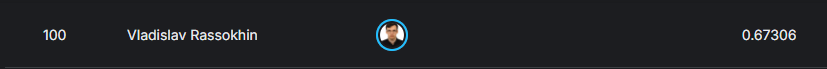